<a href="https://colab.research.google.com/github/nairarafeek/ict_assignments/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [40]:
data = pd.read_csv('/content/car_age_price.csv')

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
x = data[['Year']]
y = data['Price']

In [43]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
print("shape of x_train",x_train.shape)
print("shape of x_test",x_test.shape)
print("shape of y_train",y_train.shape)
print("shape of y_test",y_test.shape)

shape of x_train (89, 1)
shape of x_test (23, 1)
shape of y_train (89,)
shape of y_test (23,)


In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [46]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

LinearRegression()

In [47]:
y_pred_lin = lin_reg.predict(x_test)

In [48]:
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

In [49]:
print("--- Linear Regression Model Performance ---")
print(f"Coefficients (Slope): {lin_reg.coef_[0]:.2f}")
print(f"Intercept: {lin_reg.intercept_:.2f}")
print(f"Mean Squared Error: {mse_lin:.2f}")
print(f"R-squared: {r2_lin:.2f}")

--- Linear Regression Model Performance ---
Coefficients (Slope): 47608.57
Intercept: -95520922.49
Mean Squared Error: 4326906256.83
R-squared: 0.37


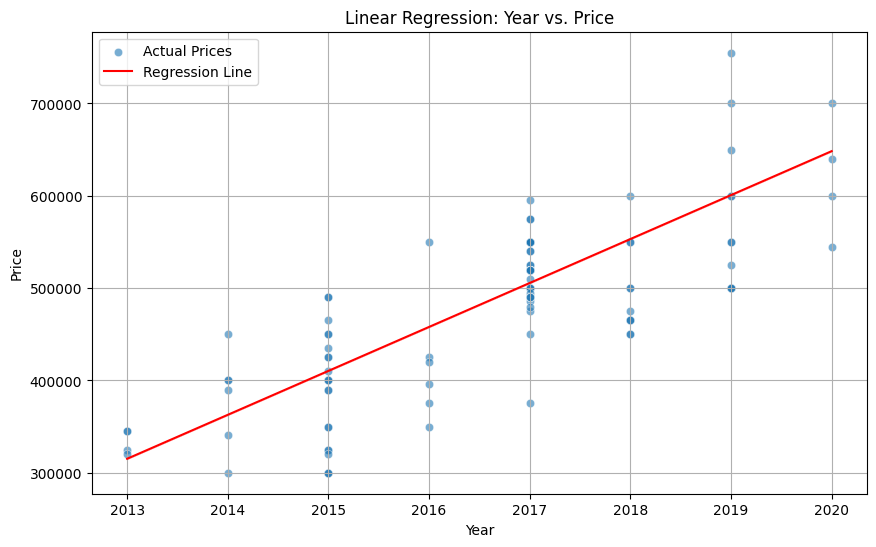

In [50]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x['Year'], y=y, label='Actual Prices', alpha=0.6)
sns.lineplot(x=x['Year'], y=lin_reg.predict(x), color='red', label='Regression Line')
plt.title('Linear Regression: Year vs. Price')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [51]:
predicted_price_2022 = lin_reg.predict([[2022]])
print(f"The predicted price for a 2022 model second-hand Grand i10 is: {predicted_price_2022[0]:.2f}")

The predicted price for a 2022 model second-hand Grand i10 is: 743601.62


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [52]:
from sklearn.linear_model import Lasso

In [53]:
lasso_reg = Lasso(alpha=0.1, random_state=42)
lasso_reg.fit(x_train, y_train)


Lasso(alpha=0.1, random_state=42)

In [54]:
y_pred_lasso = lasso_reg.predict(x_test)

In [55]:
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

In [56]:
print("--- Lasso Regression Model Performance ---")
print(f"Coefficients (Slope): {lasso_reg.coef_[0]:.2f}")
print(f"Intercept: {lasso_reg.intercept_:.2f}")
print(f"Mean Squared Error: {mse_lasso:.2f}")
print(f"R-squared: {r2_lasso:.2f}")

--- Lasso Regression Model Performance ---
Coefficients (Slope): 47608.53
Intercept: -95520839.37
Mean Squared Error: 4326901608.20
R-squared: 0.37


In [57]:
print("\n--- Model Performance Comparison ---")
print(f"Linear Regression R-squared: {r2_lin:.2f}, MSE: {mse_lin:.2f}")
print(f"Lasso Regression R-squared: {r2_lasso:.2f}, MSE: {mse_lasso:.2f}")


--- Model Performance Comparison ---
Linear Regression R-squared: 0.37, MSE: 4326906256.83
Lasso Regression R-squared: 0.37, MSE: 4326901608.20


In [58]:
print("\n--- 2022 Model Price Prediction ---")


--- 2022 Model Price Prediction ---


In [59]:
predicted_price_2022_lin = lin_reg.predict([[2022]])
print(f"Linear Regression Predicted Price (2022): {predicted_price_2022_lin[0]:.2f}")

Linear Regression Predicted Price (2022): 743601.62


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [60]:
predicted_price_2022_lasso = lasso_reg.predict([[2022]])
print(f"Lasso Regression Predicted Price (2022): {predicted_price_2022_lasso[0]:.2f}")

Lasso Regression Predicted Price (2022): 743601.39


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [61]:
if r2_lin > r2_lasso:
    print("\nBased on R-squared, Linear Regression performed slightly better on this dataset.")
elif r2_lasso > r2_lin:
    print("\nBased on R-squared, Lasso Regression performed slightly better on this dataset.")
else:
    print("\nBoth Linear and Lasso Regression models performed similarly on this dataset in terms of R-squared.")


Based on R-squared, Lasso Regression performed slightly better on this dataset.
